In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from io import BytesIO
import requests
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

from data_prepocessing import full_preprocess

torch.manual_seed(42) # Set manual seed

In [3]:
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cpu


In [4]:
def download_and_preprocess(url):
    IMAGE_SIZE = (224, 224)
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize(IMAGE_SIZE)
        img_array = img_to_array(img)
        return preprocess_input(img_array)
    except Exception as e:
        print(f"Failed to download: {url} | Error: {e}")
        return None

def save_preprocessed_images(df, image_path, indices_path):
    """Save preprocessed images and their indices"""
    # Save the image arrays
    np.save(image_path, np.stack(df['image_array'].values))
    # Save the corresponding DataFrame indices
    np.save(indices_path, df.index.values)
    print(f"Saved {len(df)} preprocessed images")

def load_preprocessed_images(df, image_path, indices_path):
    """Load preprocessed images and match them with the DataFrame"""
    # Load images and indices
    image_arrays = np.load(image_path)
    saved_indices = np.load(indices_path)
    
    # Create a dictionary mapping indices to image arrays
    image_dict = dict(zip(saved_indices, image_arrays))
    
    # Create new column by mapping current indices to saved images
    df['image_array'] = df.index.map(image_dict)
    
    # Filter rows where image loading was successful
    df = df[df['image_array'].notnull()]
    print(f"Loaded {len(df)} preprocessed images")
    return df

In [5]:
## trim off 
def load_and_trim_data(train_path, test_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    train_df = full_preprocess(train_df)
    test_df = full_preprocess(test_df)
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

def preprocess_images(train_df, test_df):
    TRAIN_IMAGE_SAVE_PATH = "train_preprocessed_images.npy"
    TRAIN_INDICES_SAVE_PATH = "train_image_indices.npy"
    TEST_IMAGE_SAVE_PATH = "test_preprocessed_images.npy"
    TEST_INDICES_SAVE_PATH = "test_image_indices.npy"
    
    if Path(TRAIN_IMAGE_SAVE_PATH).exists():
        print("Loading preprocessed images from disk")
        train_df = train_df[train_df['picture_url'].notnull()]
        train_df = load_preprocessed_images(train_df, TRAIN_IMAGE_SAVE_PATH, TRAIN_INDICES_SAVE_PATH)
    else:
        print("Downloading and preprocessing images")
        train_df = train_df[train_df['picture_url'].notnull()]
        tqdm.pandas()
        train_df['image_array'] = train_df['picture_url'].progress_apply(download_and_preprocess)
        train_df = train_df[train_df['image_array'].notnull()]
        save_preprocessed_images(train_df, TRAIN_IMAGE_SAVE_PATH, TRAIN_INDICES_SAVE_PATH)
        
    train_image_arrays = np.stack(train_df['image_array'].values)
    train_df = train_df[train_df['image_array'].notnull()].reset_index(drop=True)
        
    if Path(TEST_IMAGE_SAVE_PATH).exists():
        print("Loading preprocessed images from disk")
        test_df = test_df[test_df['picture_url'].notnull()]
        test_df = load_preprocessed_images(test_df, TEST_IMAGE_SAVE_PATH, TEST_INDICES_SAVE_PATH)
    else:
        print("Downloading and preprocessing images")
        test_df = test_df[test_df['picture_url'].notnull()]
        tqdm.pandas()
        test_df['image_array'] = test_df['picture_url'].progress_apply(download_and_preprocess)
        test_df = test_df[test_df['image_array'].notnull()]
        save_preprocessed_images(test_df, TEST_IMAGE_SAVE_PATH, TEST_INDICES_SAVE_PATH)

    test_image_arrays = np.stack(test_df['image_array'].values)
    test_df = test_df[test_df['image_array'].notnull()].reset_index(drop=True)
    
    return train_image_arrays, test_image_arrays, train_df, test_df


def preprocess_text_num(train_df, test_df, num_words=10000, maxlen=200):
    numerical_cols = ["accommodates", "bedrooms", "beds", "bathrooms", "latitude", "longitude"]
    amenity_cols = [col for col in train_df.columns
                    if col not in numerical_cols + ['price', 'description'] and train_df[col].dtype == bool]
    tabular_cols = numerical_cols + amenity_cols

    train_df[tabular_cols] = train_df[tabular_cols].fillna(train_df[tabular_cols].mean())
    test_df[tabular_cols] = test_df[tabular_cols].fillna(train_df[tabular_cols].mean())

    scaler = MinMaxScaler()
    X_tabular_train = scaler.fit_transform(train_df[tabular_cols])
    X_tabular_test = scaler.transform(test_df[tabular_cols])

    tokenizer = Tokenizer(num_words=num_words)
    tokenizer.fit_on_texts(train_df["description"].apply(lambda x: " ".join(map(str, x))))
    X_text_train = pad_sequences(tokenizer.texts_to_sequences(
        train_df["description"].apply(lambda x: " ".join(map(str, x)))), maxlen=maxlen)
    X_text_test = pad_sequences(tokenizer.texts_to_sequences(
        test_df["description"].apply(lambda x: " ".join(map(str, x)))), maxlen=maxlen)

    y_train = train_df["price"].values
    y_test = test_df["price"].values

    return X_tabular_train, X_tabular_test, X_text_train, X_text_test, y_train, y_test, tokenizer.word_index

# Load and preprocess the data
train_df, test_df = load_and_trim_data("train_listings.csv", "test_listings.csv")
X_image_train, X_image_test, train_df, test_df = preprocess_images(train_df, test_df)
X_tabular_train, X_tabular_test, X_text_train, X_text_test, y_train, y_test, word_index = preprocess_text_num(train_df, test_df)

C:\MSc. Phys\SS25\machine learning\practical\final\data_prepocessing.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
C:\MSc. Phys\SS25\machine learning\practical\final\data_prepocessing.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price"].replace({r'\$': '',',':

C:\Users\sonin\anaconda3\Lib\site-packages\PIL\Image.py:3402: DecompressionBombWarning: Image size (149970000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
C:\Users\sonin\anaconda3\Lib\site-packages\PIL\Image.py:3402: DecompressionBombWarning: Image size (96850215 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
 66%|███████████████████████████████████████████████████▌                          | 3158/4776 [56:28<17:50,  1.51it/s]

Failed to download: https://a0.muscache.com/pictures/miso/Hosting-1408824064964092927/original/dec7e76d-ae24-48f7-99a6-d9cab1e4180a.jpeg | Error: cannot identify image file <_io.BytesIO object at 0x0000022E70E73970>


 88%|██████████████████████████████████████████████████████████████████▌         | 4184/4776 [1:13:49<07:20,  1.34it/s]

Failed to download: https://a0.muscache.com/pictures/miso/Hosting-1426966173729206254/original/47be7960-db78-4ecb-8827-16e0b94a4ebd.jpeg | Error: cannot identify image file <_io.BytesIO object at 0x0000022E70F47C40>


100%|████████████████████████████████████████████████████████████████████████████| 4776/4776 [1:24:17<00:00,  1.06s/it]


Saved 4774 preprocessed images


C:\Users\sonin\anaconda3\Lib\site-packages\PIL\Image.py:3402: DecompressionBombWarning: Image size (149970000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████| 1202/1202 [21:28<00:00,  1.07s/it]


Saved 1202 preprocessed images


In [7]:
X_text_test.shape, X_image_test.shape

((1202, 200), (1202, 224, 224, 3))

In [8]:
class HybridModel(nn.Module):
    def __init__(self, vocab_size, text_embed_dim, tabular_input_dim, text_seq_len, image_output_dim=128):
        super(HybridModel, self).__init__()

        # Tabular branch
        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Text branch
        self.embedding = nn.Embedding(vocab_size + 1, text_embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(text_embed_dim, 64, batch_first=True)
        self.text_dropout = nn.Dropout(0.3)

        # Image branch
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])  # Remove fully connected layers
        self.image_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(resnet.fc.in_features, image_output_dim),
            nn.ReLU()
        )

        # Combined branch
        self.combined_fc = nn.Sequential(
            nn.Linear(64 + 64 + image_output_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # Predict price
        )

    def forward(self, tabular_input, text_input, image_input):
        x_tab = self.tabular_fc(tabular_input)
        x_text = self.embedding(text_input)
        _, (h_n, _) = self.lstm(x_text)
        x_text = self.text_dropout(h_n[-1])
        x_img = self.image_fc(self.resnet(image_input))
        x = torch.cat([x_tab, x_text, x_img], dim=1)
        return self.combined_fc(x)

In [9]:
# Split train and validate
X_tab_train, X_tab_val, \
X_text_train, X_text_val, \
X_img_train, X_img_val, \
y_train, y_val = train_test_split(
    X_tabular_train, X_text_train, X_image_train, y_train, test_size=0.2, random_state=42)

In [10]:
# Create dataset and dataloader
bsize = 32

class AirbnbDataset(Dataset):
    def __init__(self, tabular, text, images, targets):
        self.tabular = torch.tensor(tabular, dtype=torch.float32)
        self.text = torch.tensor(text, dtype=torch.long)
        self.images = torch.tensor(images, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.targets)
    
    ## permute so that the dimension match expectation of image in pytorch
    def __getitem__(self, idx):
        return self.tabular[idx], self.text[idx], self.images[idx].permute(2, 0, 1), self.targets[idx] 
    
## Create datasets
train_dataset = AirbnbDataset(X_tab_train, X_text_train, X_img_train, y_train)
val_dataset = AirbnbDataset(X_tab_val, X_text_val, X_img_val, y_val)

## Create dataloaders
train_loader = DataLoader(train_dataset, batch_size = bsize, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = bsize)

In [11]:
model = HybridModel(
    vocab_size=len(word_index),
    text_embed_dim=64,
    tabular_input_dim=X_tabular_train.shape[1],
    text_seq_len=X_text_train.shape[1]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_function = nn.MSELoss()

C:\Users\sonin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sonin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\sonin/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:20<00:00, 4.91MB/s]


In [12]:
def train(model, loader, optimizer, loss_function, device):
    losses = []
    model.train()
    for tab, text, img, target in loader:
        tab, text, img, target = tab.to(device), text.to(device), img.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(tab, text, img)
        loss = loss_function(output, target)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

def val(model, loader, loss_function, device):
    losses = []
    model.eval()
    with torch.no_grad():
        for tab, text, img, target in loader:
            tab, text, img, target = tab.to(device), text.to(device), img.to(device), target.to(device)
            output = model(tab, text, img)
            loss = loss_function(output, target)
            losses.append(loss.item())
    return np.mean(losses)

def run_training(model, optimizer, loss_function, train_dataloader, val_dataloader, num_epochs, device):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        train_loss = train(model, train_dataloader, optimizer, loss_function, device)
        val_loss = val(model, val_dataloader, loss_function, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    return train_losses, val_losses

In [13]:
epochs = 50

train_loss, val_loss = run_training(model, optimizer, loss_function, train_loader, val_loader, epochs, device)

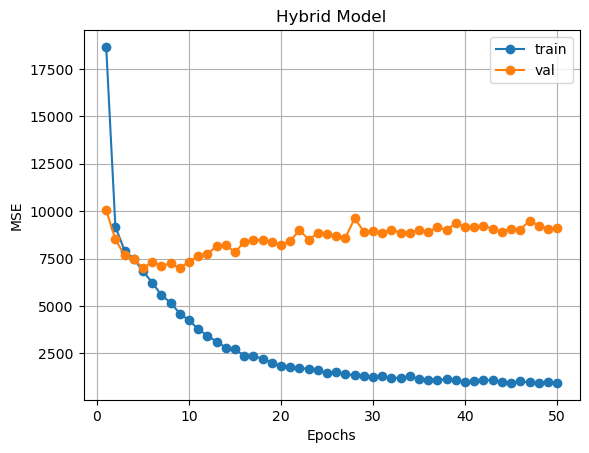

In [21]:
plt.plot(range(1, epochs + 1), train_loss, marker = "o", label = "train")
plt.plot(range(1, epochs + 1), val_loss, marker = "o", label = "val")

plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Hybrid Model")
plt.grid()
plt.legend()
plt.savefig("Hybrid Model.jpg")

In [22]:
test_dataset = AirbnbDataset(
    X_tabular_test,
    X_text_test,
    X_image_test,
    y_test 
)

test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)

In [23]:
model.eval()
price_preds = []
price_trues = []

with torch.no_grad():
    for tab, text, img, target in test_loader:
        tab, text, img, target = tab.to(device), text.to(device), img.to(device), target.to(device)

        output = model(tab, text, img)
        price_preds.extend(output.squeeze().cpu().numpy())
        price_trues.extend(target.cpu().numpy())

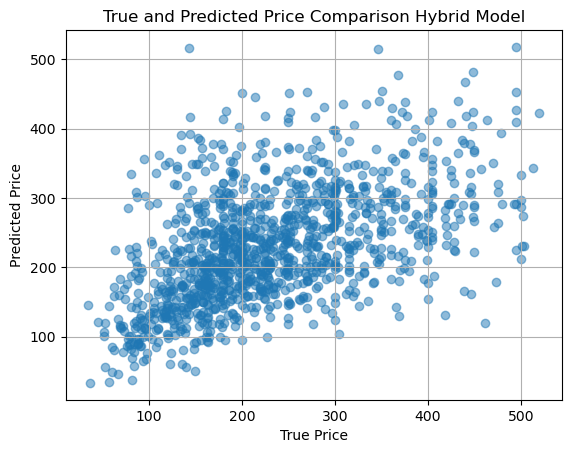

In [26]:
plt.scatter(price_trues, price_preds, alpha = 0.5)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("True and Predicted Price Comparison Hybrid Model")
plt.grid()
plt.savefig("truepred_hybrid.jpg")